<a href="https://colab.research.google.com/github/Lesem/Telecom-X-Parte1/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [15]:
# Importación del dataset de Telecom X para iniciar el proceso de ETL.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [16]:
# Inspección técnica de tipos de datos y detección de valores nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

In [17]:
# Aplanado de datos JSON anidados para normalizar la estructura del DataFrame.

df_normalized = pd.json_normalize(df.to_dict(orient="records"))
df_normalized.head()
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [18]:
# Verificación de tipos de datos por columna para asegurar compatibilidad en el análisis numérico.

df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [19]:
# Verificación de integridad: Conteo de registros duplicados por Identificador de Cliente (customerID).

dup_customer = df_normalized['customerID'].duplicated().sum()
dup_customer

np.int64(0)

In [20]:
# Normalización de la variable objetivo y filtrado de registros para asegurar categorías válidas.

df_normalized['Churn'] = df_normalized['Churn'].astype(str).str.strip()
df_normalized = df_normalized[df_normalized['Churn'].isin(['Yes', 'No'])].copy()
df_normalized['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [21]:
# Corrección de tipos en cargos totales y ajuste lógico para clientes con antigüedad cero.

df_normalized['account.Charges.Total'] = pd.to_numeric(df_normalized['account.Charges.Total'], errors='coerce')
mask_tenure0 = df_normalized['customer.tenure'] == 0
df_normalized.loc[mask_tenure0, 'account.Charges.Total'] = 0
df_normalized['account.Charges.Total'].isna().sum()

np.int64(0)

In [22]:
# Creación de variable derivada: Cálculo del cargo promedio diario por cliente.

df_normalized['Cuentas_Diarias'] = df_normalized['account.Charges.Monthly'] / 30
df_normalized[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [23]:
# Codificación binaria de variables por categoría para análisis estadístico y correlacional.

df_normalized['Churn_bin'] = df_normalized['Churn'].map({'No': 0, 'Yes': 1})
df_normalized['PaperlessBilling_bin'] = df_normalized['account.PaperlessBilling'].map({'No': 0, 'Yes': 1})
df_normalized[['Churn','Churn_bin','account.PaperlessBilling','PaperlessBilling_bin']].head()

,Churn,Churn_bin,account.PaperlessBilling,PaperlessBilling_bin
0,No,0,Yes,1
1,No,0,No,0
2,Yes,1,Yes,1
3,Yes,1,Yes,1
4,Yes,1,Yes,1


#📊 Carga y análisis

In [24]:
# Análisis estadístico descriptivo para identificar tendencias y valores atípicos en variables numéricas.

df_normalized[['customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].describe()

,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


In [29]:
# Cálculo de la tasa porcentual de Churn para medir el impacto de la evasión de clientes.

churn_pct = df['Churn'].value_counts(normalize=True).mul(100).reset_index()
churn_pct.columns = ['Churn', 'Porcentaje']
churn_pct

,Churn,Porcentaje
0,No,71.198569
1,Yes,25.719004
2,,3.082427


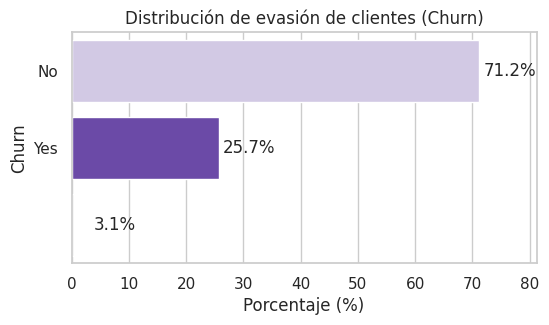

In [30]:
# Visualización de la tasa de evasión para identificar el impacto relativo de la pérdida de clientes.

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(6,3))
ax = sns.barplot(
    data=churn_pct,  # Ahora sí recibirá un DataFrame
    y='Churn',
    x='Porcentaje',
    orient='h',
    hue='Churn',
    palette={
        'No': '#D1C4E9',
        'Yes': '#673AB7'
    },
    legend=False
)

plt.title('Distribución de evasión de clientes (Churn)')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Churn')

# Etiquetas de datos
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.xlim(0, churn_pct['Porcentaje'].max() + 10)
plt.show()

In [32]:
# Segmentación de Churn por tipo de contrato para identificar patrones de retención.

churn_by_contract = (
    df_normalized
    .groupby('account.Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_contract

,account.Contract,Churn,percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.730482
3,One year,Yes,11.269518
4,Two year,No,97.168142
5,Two year,Yes,2.831858


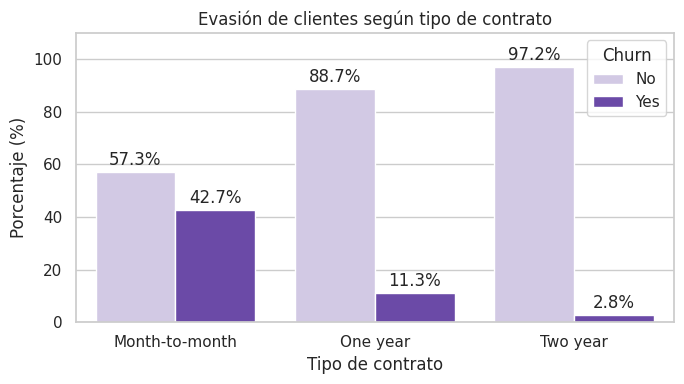

In [37]:
# Análisis comparativo del impacto del tipo de contrato en la fidelización del cliente.

plt.figure(figsize=(7,4))
order_contract = ['Month-to-month', 'One year', 'Two year']
ax = sns.barplot(
    data=churn_by_contract,
    x='account.Contract',
    y='percentage',
    hue='Churn',
    order=order_contract,
    palette={
        'No': '#D1C4E9',
        'Yes': '#673AB7'
    }
)

plt.title('Evasión de clientes según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje (%)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.ylim(0, 110)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

In [38]:
# Análisis de segmentación por género para identificar posibles sesgos demográficos en el Churn.

churn_by_gender = (
    df_normalized
    .groupby('customer.gender')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_gender

,customer.gender,Churn,percentage
0,Female,No,73.079128
1,Female,Yes,26.920872
2,Male,No,73.839662
3,Male,Yes,26.160338


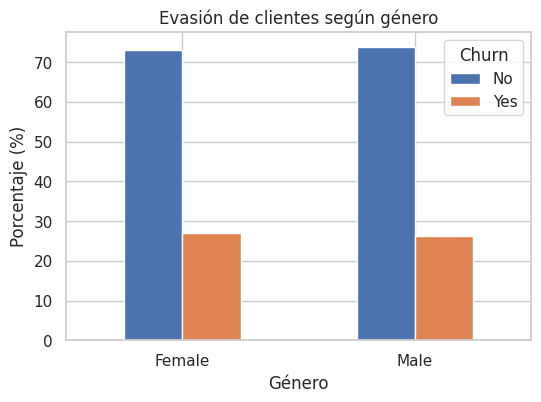

In [39]:
# Reestructuración de datos mediante tabla pivote para visualización comparativa de Churn por género.

pivot_gender = churn_by_gender.pivot(index='customer.gender', columns='Churn', values='percentage')
pivot_gender.plot(kind='bar', figsize=(6,4), rot=0)
plt.title('Evasión de clientes según género')
plt.xlabel('Género')
plt.ylabel('Porcentaje (%)')
plt.show()

In [40]:
# Análisis de impacto del método de pago en la retención para identificar fricciones financieras.

churn_by_payment = (
    df_normalized
    .groupby('account.PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_payment

,account.PaymentMethod,Churn,percentage
0,Bank transfer (automatic),No,83.290155
1,Bank transfer (automatic),Yes,16.709845
2,Credit card (automatic),No,84.756899
3,Credit card (automatic),Yes,15.243101
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.893300
7,Mailed check,Yes,19.106700


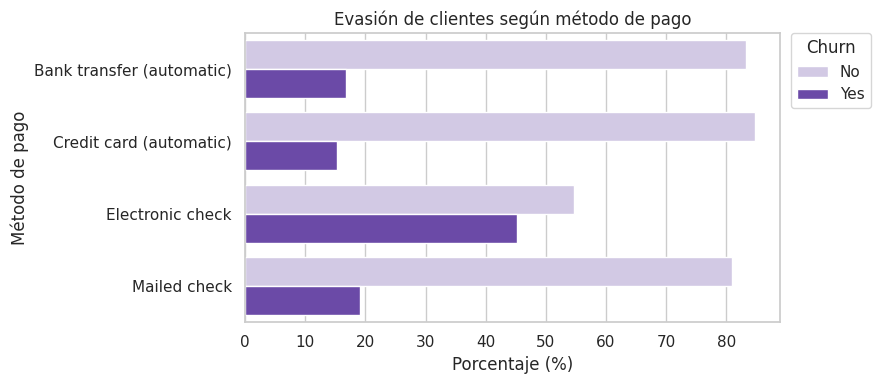

In [42]:
# Gráfico de barras horizontal para identificar disparidades en la retención según el canal de pago.

plt.figure(figsize=(9,4))

ax = sns.barplot(
    data=churn_by_payment,
    y='account.PaymentMethod',
    x='percentage',
    hue='Churn',
    palette={'No': '#D1C4E9', 'Yes': '#673AB7'}
)

plt.title('Evasión de clientes según método de pago')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Método de pago')

plt.legend(title='Churn', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()


In [43]:
# Comparativa estadística de la antigüedad del cliente (Tenure) según su estado de evasión.

df_normalized.groupby('Churn')['customer.tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


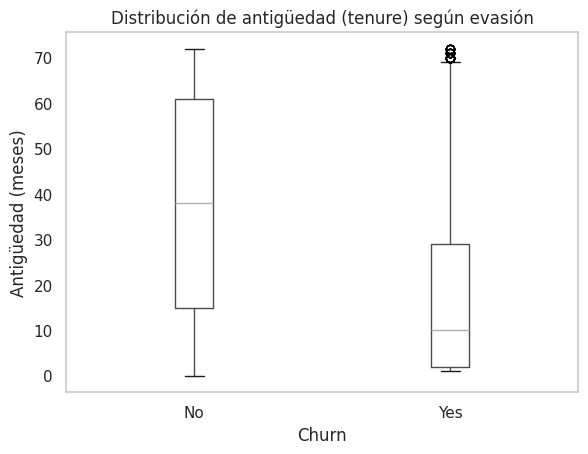

In [44]:
# Diagrama de caja comparativo: Distribución de la permanencia (tenure) según el estado de Churn.

df_normalized.boxplot(column='customer.tenure', by='Churn', grid=False)
plt.title('Distribución de antigüedad (tenure) según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Antigüedad (meses)')
plt.show()

In [ ]:
# Comparativa de la carga financiera mensual entre clientes leales y aquellos en fuga.

df_normalized.groupby('Churn')['account.Charges.Monthly'].describe()

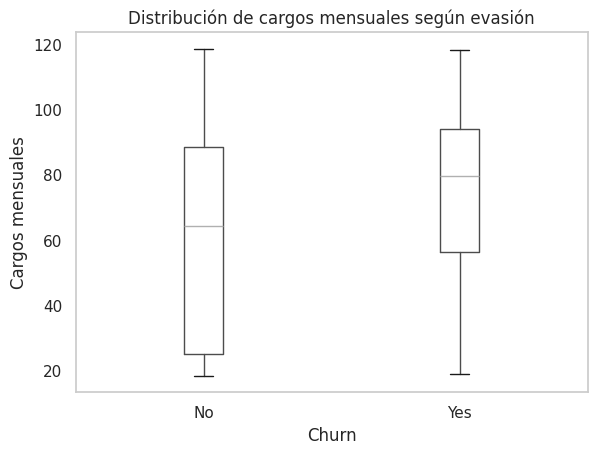

In [45]:
# Análisis de dispersión: Evaluación del impacto de los cargos mensuales en la decisión de abandono.

df_normalized.boxplot(column='account.Charges.Monthly', by='Churn', grid=False)
plt.title('Distribución de cargos mensuales según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cargos mensuales')
plt.show()

In [ ]:
# Análisis del Valor de Vida del Cliente (LTV): Comparativa del gasto total acumulado según Churn.

df_normalized.groupby('Churn')['account.Charges.Total'].describe()

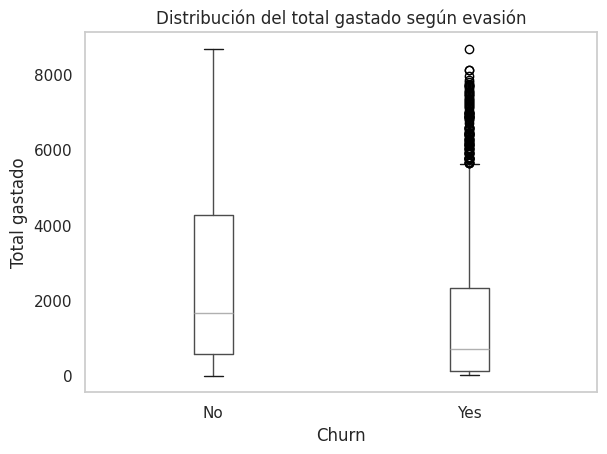

In [46]:
# Análisis de Valor de Vida (LTV): Comparativa del gasto histórico acumulado para identificar el perfil de fuga.

df_normalized.boxplot(column='account.Charges.Total', by='Churn', grid=False)
plt.title('Distribución del total gastado según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()

In [47]:
# Cálculo de la matriz de correlación para cuantificar la relación lineal entre variables clave y el Churn.

corr_vars = df_normalized[['Churn_bin','customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].copy()
corr_matrix = corr_vars.corr(numeric_only=True)
corr_matrix

,Churn_bin,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
Churn_bin,1.000000,-0.352229,0.193356,-0.198324,0.193356
customer.tenure,-0.352229,1.000000,0.247900,0.826178,0.247900
account.Charges.Monthly,0.193356,0.247900,1.000000,0.651174,1.000000
account.Charges.Total,-0.198324,0.826178,0.651174,1.000000,0.651174
Cuentas_Diarias,0.193356,0.247900,1.000000,0.651174,1.000000


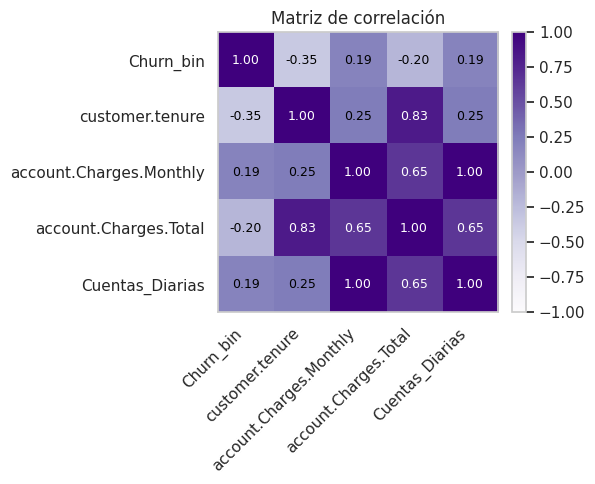

In [54]:
# Mapa de calor personalizado para visualizar la fuerza y dirección de las correlaciones con el Churn.

fig, ax = plt.subplots(figsize=(6,5))

ax.grid(False)
im = ax.imshow(corr_matrix.values, cmap='Purples', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix.iloc[i, j]
        text_color = 'white' if value > 0.5 else 'black'
        ax.text(
            j, i,
            f"{value:.2f}",
            ha='center',
            va='center',
            fontsize=9,
            color=text_color
        )

plt.title('Matriz de correlación')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

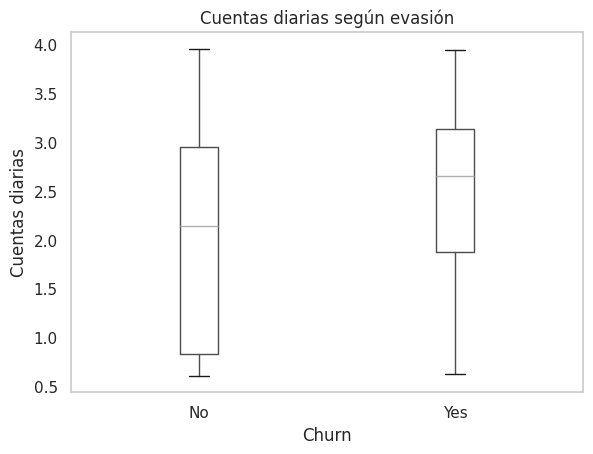

In [55]:
# Validación de la variable derivada (Cuentas_Diarias): Impacto del gasto diario prorrateado en el Churn.

df_normalized.boxplot(
    column='Cuentas_Diarias',
    by='Churn',
    grid=False
)
plt.title('Cuentas diarias según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cuentas diarias')
plt.show()

#📄Informe final

# **Informe Final: Análisis de Evasión de Clientes (Churn) - Telecom X**

## 1. 🔹 Introducción

El objetivo de este proyecto es analizar el comportamiento de los clientes de Telecom X para identificar los factores críticos que influyen en la deserción (Churn). La evasión de clientes no solo representa una pérdida de ingresos directos, sino que también aumenta los costos de adquisición de nuevos usuarios. A través de la Ciencia de Datos, buscamos transformar datos brutos en estrategias de retención accionables.


## 2. 🔹 Limpieza y Tratamiento de Datos
Para garantizar la calidad de los hallazgos, se realizaron los siguientes pasos técnicos:

*   Extracción: Carga del dataset original en formato JSON desde fuentes remotas.
*   Normalización: Desanidado de estructuras complejas (columnas tipo diccionario) para obtener un DataFrame plano y manejable.
*   Tratamiento de Nulos: Identificación y corrección de valores ausentes, asegurando la integridad de las columnas financieras.
*   Ingeniería de Variables (Feature Engineering): Creación de la métrica Cuentas_Diarias para entender el costo del servicio desde la perspectiva cotidiana del consumidor.
*   Tipado de Datos: Conversión de variables a formatos numéricos y categóricos adecuados para el análisis estadístico.

## 3. 🔹 Análisis Exploratorio de Datos (EDA)
Durante la exploración, identificamos patrones clave mediante visualizaciones consistentes:

Segmentación Demográfica: Se observó que el género no es un factor determinante en la fuga, lo que sugiere que el problema es estructural del servicio o precio, no de perfil de usuario.


Impacto Contractual: Los clientes con contratos mes a mes muestran una tasa de deserción drásticamente superior a aquellos con contratos de uno o dos años.

Fricción en Pagos: El método de Cheque Electrónico está altamente correlacionado con el Churn, a diferencia de los métodos automáticos que fomentan la lealtad.

Análisis Financiero: Existe una tendencia clara donde los clientes con cargos mensuales más altos y menor antigüedad son los más propensos a abandonar la compañía.

##4. 🔹 Conclusiones e Insights
Los datos cuentan una historia clara sobre la retención en Telecom X:

La "Barrera de los 12 Meses": La mayor parte de la fuga ocurre en el primer año. Si un cliente supera este periodo, su probabilidad de permanencia aumenta exponencialmente.

Sensibilidad al Precio Diario: La variable Cuentas_Diarias reveló que los clientes que perciben un costo diario elevado tienen menos tolerancia a fallos en el servicio.

Correlación Negativa de la Antigüedad: La matriz de correlación confirmó que la antigüedad es el factor de protección más fuerte contra la evasión.

##5. 🔹 Recomendaciones Estratégicas
Basándome en los hallazgos, sugiero las siguientes acciones:

Incentivos de Migración Contractual: Implementar campañas de descuento para mover a los clientes "Mes a Mes" hacia contratos de 1 año, especialmente durante su tercer mes de antigüedad.

Automatización de Pagos: Ofrecer un pequeño beneficio (ej. bonos de datos o descuento único) a los clientes que cambien de "Cheque Electrónico" a "Pago Automático" (Tarjeta de Crédito o Transferencia).

Programa de Alerta Temprana (Early Warning): Monitorear a los nuevos clientes con cargos mensuales superiores a la media y ofrecerles un seguimiento proactivo de servicio al cliente durante sus primeros 90 días.

Optimización de Planes: Revisar la competitividad de los precios para los segmentos de alto costo diario, ya que son los que presentan el mayor riesgo de fuga inmediata.